In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("data/raw/online.csv")

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.shape

(1067371, 8)

In [5]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER    5918
REGENCY CAKESTAND 3 TIER              4412
JUMBO BAG RED RETROSPOT               3469
ASSORTED COLOUR BIRD ORNAMENT         2958
PARTY BUNTING                         2765
                                      ... 
wet?                                     1
lost??                                   1
???                                      1
wet boxes                                1
????damages????                          1
Name: count, Length: 5698, dtype: int64

In [6]:
df['StockCode'].value_counts()

StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259
          ... 
85049c       1
84971l       1
85034b       1
23609        1
23617        1
Name: count, Length: 5305, dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [9]:
(df.isnull().sum() / len(df)) * 100

Invoice         0.000000
StockCode       0.000000
Description     0.410541
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    22.766873
Country         0.000000
dtype: float64

In [10]:
df = df.dropna(subset=['Customer ID','Description'])

In [11]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(26479)

In [13]:
df = df.drop_duplicates()

In [14]:
(df['Quantity'] < 0).sum()

np.int64(18390)

In [15]:
df['Invoice'].astype(str).str.startswith('C').sum()

np.int64(18390)

In [16]:
df['Returned'] = df['Quantity'].apply(lambda x: 1 if x < 0 else 0)

In [17]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Returned
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,0


In [18]:
df['Quantity'] = df['Quantity'].abs()

In [19]:
df['Returned'].value_counts()

Returned
0    779495
1     18390
Name: count, dtype: int64

In [20]:
df['StockCode'].nunique()

4646

In [21]:
df['Customer ID'].nunique()

5942

In [22]:
df['Description'].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    5149
REGENCY CAKESTAND 3 TIER              3678
JUMBO BAG RED RETROSPOT               2713
ASSORTED COLOUR BIRD ORNAMENT         2709
PARTY BUNTING                         2121
LUNCH BAG  BLACK SKULL.               2089
STRAWBERRY CERAMIC TRINKET BOX        2040
POSTAGE                               1983
BAKING SET 9 PIECE RETROSPOT          1961
REX CASH+CARRY JUMBO SHOPPER          1959
Name: count, dtype: int64

In [23]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           161990
MEDIUM CERAMIC TOP STORAGE JAR        152410
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106865
WHITE HANGING HEART T-LIGHT HOLDER     95388
ASSORTED COLOUR BIRD ORNAMENT          78713
JUMBO BAG RED RETROSPOT                75415
BROCADE RING PURSE                     70821
PACK OF 60 PINK PAISLEY CAKE CASES     54811
60 TEATIME FAIRY CAKE CASES            53154
PACK OF 72 RETRO SPOT CAKE CASES       45778
Name: Quantity, dtype: int64

In [24]:
product_returns = df.groupby('Description')['Returned'].mean().sort_values(ascending=False)
product_returns.head(10)

Description
ZINC HEART HANGER WITH HOOKS           1.0
S/4 HEART CRYSTAL FRIDGE MAGNETS       1.0
LARGE SILVER BALUSTRADE CANDLESTICK    1.0
SET 6 MINI SUSHI SET FRIDGE MAGNETS    1.0
CRUK Commission                        1.0
PINK EAR MUFF HEADPHONES               1.0
BLUE GREEN CHRISTMAS HANGING BALL      1.0
WHITE ORCHID FLOWER LIGHTS             1.0
PURPLE ORCHID FLOWER LIGHTS            1.0
LARGE GLASS HEART TRINKET POT          1.0
Name: Returned, dtype: float64

In [26]:
df['TotalPrice'] = df['Quantity']*df['Price']

In [28]:
df[['Quantity','Price','TotalPrice']].head()

,Quantity,Price,TotalPrice
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [29]:
df['TotalPrice'].sort_values(ascending=False).head(10)

1065882    168469.60
1065883    168469.60
587085      77183.60
587080      77183.60
748142      38970.00
748132      38970.00
241824      25111.09
432176      15818.40
135013      10953.50
135012      10953.50
Name: TotalPrice, dtype: float64

In [30]:
import datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [31]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Returned,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,0,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,0,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,0,30.0


In [32]:
df['year'] = df['InvoiceDate'].dt.year
df['month'] = df['InvoiceDate'].dt.month
df['day'] = df['InvoiceDate'].dt.day
df['hour'] = df['InvoiceDate'].dt.hour
df['day_of_week'] = df['InvoiceDate'].dt.dayofweek

In [33]:
df[['InvoiceDate','year','month','hour','day_of_week']].head()

,InvoiceDate,year,month,hour,day_of_week
0,2009-12-01 07:45:00,2009,12,7,1
1,2009-12-01 07:45:00,2009,12,7,1
2,2009-12-01 07:45:00,2009,12,7,1
3,2009-12-01 07:45:00,2009,12,7,1
4,2009-12-01 07:45:00,2009,12,7,1


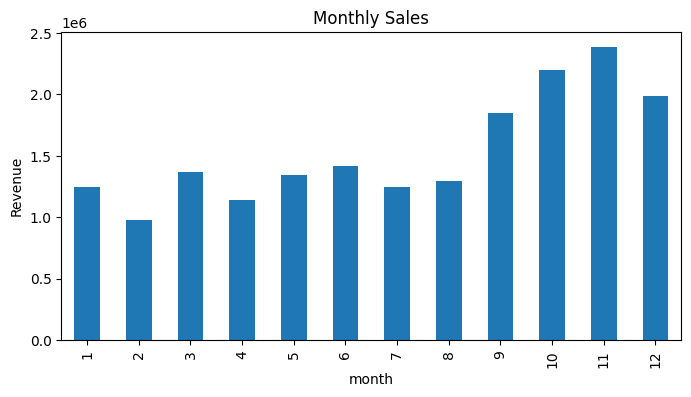

In [34]:
monthly_sales = df.groupby('month')['TotalPrice'].sum()

plt.figure(figsize=(8,4))
monthly_sales.plot(kind='bar')
plt.title("Monthly Sales")
plt.ylabel("Revenue")
plt.show()

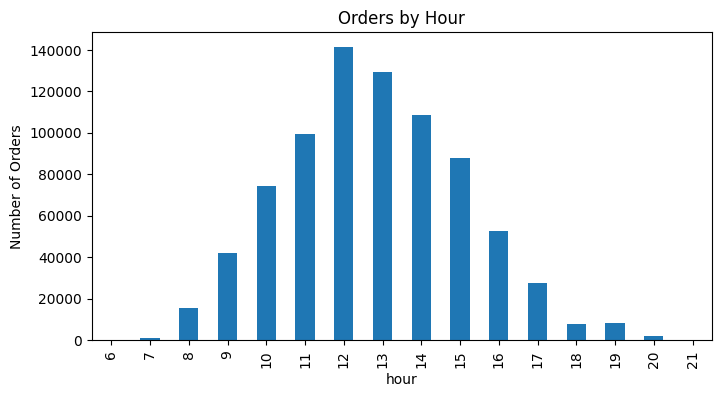

In [36]:
hourly_sales = df.groupby('hour')['Invoice'].count()

plt.figure(figsize=(8,4))
hourly_sales.plot(kind='bar')
plt.title("Orders by Hour")
plt.ylabel("Number of Orders")
plt.show()

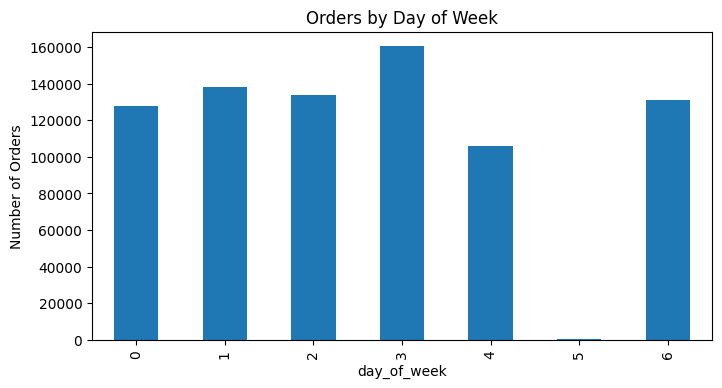

In [38]:
weekday_sales = df.groupby('day_of_week')['Invoice'].count()

plt.figure(figsize=(8,4))
weekday_sales.plot(kind='bar')
plt.title("Orders by Day of Week")
plt.ylabel("Number of Orders")
plt.show()

In [39]:
df['Returned'].mean()


np.float64(0.023048434298175803)

In [40]:
country_returns = df.groupby('Country')['Returned'].mean().sort_values(ascending=False)

country_returns.head(10)

Country
USA                0.235514
Japan              0.171681
Czech Republic     0.166667
Korea              0.158730
Saudi Arabia       0.100000
Channel Islands    0.057716
Malta              0.056856
Australia          0.051852
Germany            0.051848
Poland             0.043643
Name: Returned, dtype: float64

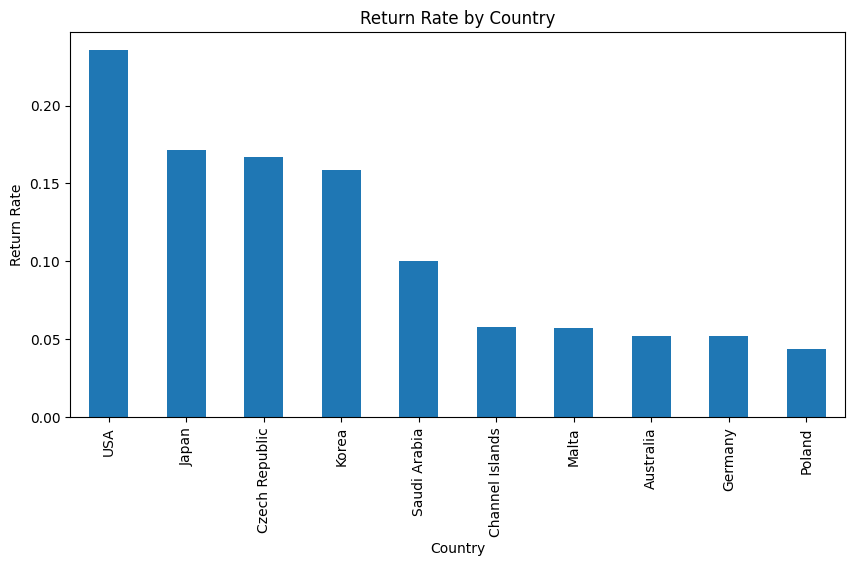

In [41]:
top_countries = country_returns.head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title("Return Rate by Country")
plt.ylabel("Return Rate")
plt.show()

In [42]:
product_returns = df.groupby('Description')['Returned'].mean().sort_values(ascending=False)

product_returns.head(10)

Description
ZINC HEART HANGER WITH HOOKS           1.0
S/4 HEART CRYSTAL FRIDGE MAGNETS       1.0
LARGE SILVER BALUSTRADE CANDLESTICK    1.0
SET 6 MINI SUSHI SET FRIDGE MAGNETS    1.0
CRUK Commission                        1.0
PINK EAR MUFF HEADPHONES               1.0
BLUE GREEN CHRISTMAS HANGING BALL      1.0
WHITE ORCHID FLOWER LIGHTS             1.0
PURPLE ORCHID FLOWER LIGHTS            1.0
LARGE GLASS HEART TRINKET POT          1.0
Name: Returned, dtype: float64

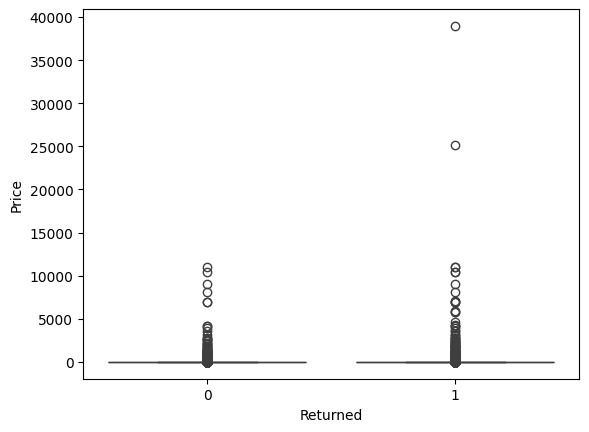

In [44]:
sns.boxplot(x='Returned', y='Price', data=df)
plt.show()

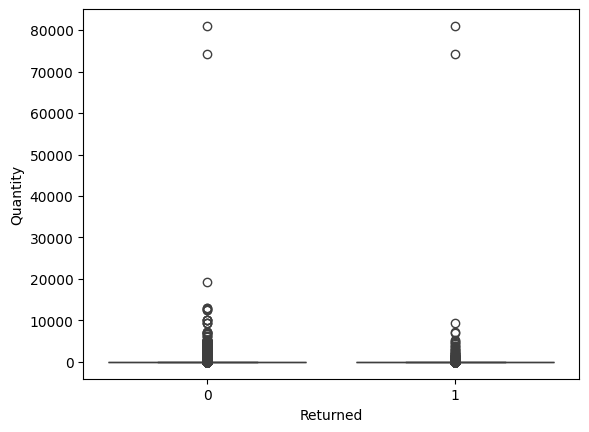

In [45]:
sns.boxplot(x='Returned', y='Quantity', data=df)
plt.show()

In [47]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Returned,TotalPrice,year,month,day,hour,day_of_week
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,0,83.4,2009,12,1,7,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0,81.0,2009,12,1,7,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0,81.0,2009,12,1,7,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,0,100.8,2009,12,1,7,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,0,30.0,2009,12,1,7,1


In [48]:
customer_spending = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False)

customer_spending.head(10)

Customer ID
18102.0    591593.47
14646.0    533862.97
16446.0    336951.10
14156.0    330811.80
14911.0    317083.71
17450.0    258177.95
13694.0    201260.54
17511.0    175774.12
12346.0    155164.66
16684.0    152783.29
Name: TotalPrice, dtype: float64

In [50]:
customer_frequency = df.groupby('Customer ID')['Invoice'].nunique().sort_values(ascending=False)

customer_frequency.head(10)

Customer ID
14911.0    510
12748.0    365
17841.0    289
15311.0    270
14606.0    259
13089.0    247
14156.0    202
14527.0    190
13694.0    164
14646.0    164
Name: Invoice, dtype: int64

In [51]:
avg_order_value = df.groupby('Customer ID')['TotalPrice'].mean().sort_values(ascending=False)

avg_order_value.head(10)

Customer ID
16446.0    67390.22
17399.0    25111.09
15098.0    15836.70
12918.0    10953.50
15760.0     6725.71
15849.0     5876.34
16981.0     4620.86
15749.0     4502.18
16151.0     4217.59
15195.0     3861.00
Name: TotalPrice, dtype: float64

In [52]:
customer_return_rate = df.groupby('Customer ID')['Returned'].mean().sort_values(ascending=False)

customer_return_rate.head(10)

Customer ID
13528.0    1.0
14120.0    1.0
15357.0    1.0
16879.0    1.0
13231.0    1.0
15383.0    1.0
16995.0    1.0
17013.0    1.0
16994.0    1.0
16853.0    1.0
Name: Returned, dtype: float64

In [55]:
customer_summary = df.groupby('Customer ID').agg({
    'TotalPrice':'sum',
    'Invoice':'nunique',
    'Returned':'mean'
})

customer_summary.columns = ['TotalSpent','PurchaseFrequency','ReturnRate']

customer_summary.head()

,TotalSpent,PurchaseFrequency,ReturnRate
Customer ID,,,
12346.0,155164.66,17,0.276596
12347.0,4921.53,8,0.000000
12348.0,2019.40,5,0.000000
12349.0,4452.84,5,0.027778
12350.0,334.40,1,0.000000


In [56]:
reference_date = df['InvoiceDate'].max()

reference_date

Timestamp('2011-12-09 12:50:00')

In [58]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

In [59]:
rfm.columns = ['Recency','Frequency','Monetary']

In [60]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,17,155164.66
12347.0,1,8,4921.53
12348.0,74,5,2019.40
12349.0,18,5,4452.84
12350.0,309,1,334.40


In [61]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

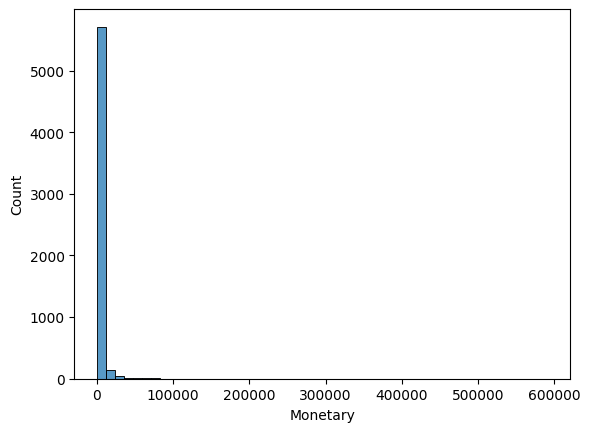

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(rfm['Monetary'], bins=50)
plt.show()

In [63]:
import numpy as np

rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

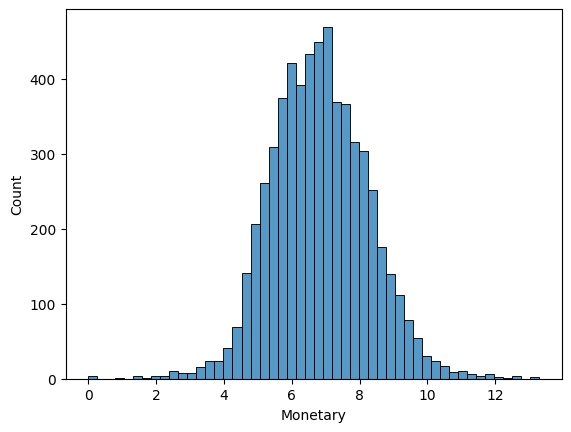

In [64]:
sns.histplot(rfm_log['Monetary'], bins=50)
plt.show()

In [70]:
os.makedirs("data/notebook_dataset", exist_ok=True)

In [71]:
df.to_csv("data/notebook_dataset/cleaned_data.csv", index=False)
rfm.to_csv("data/notebook_dataset/rfm_table.csv")
rfm_log.to_csv("data/notebook_dataset/rfm_log_table.csv")